# Democrasim: elections on measured stakes

This notebook walks the core loop: **real households**, two **actual encoded reforms**, engine-computed **true impacts**, one labeled **perception** assumption, and pluggable **voting rules** — then asks how accurately voters must perceive their own stakes before elections reliably pick the welfare-optimal policy.

> **What this is and isn't.** A thought experiment about one mechanism (self-interested voting under misperception of engine-computed household impacts). It is not political science: real voters weigh values, identity, and information far beyond their own net income. It is never election prediction. Platforms are generic (Policy A / Policy B), not candidates or parties. Every number below is a model result, not observed data.

In [1]:
%matplotlib inline
import numpy as np
import democrasim as d

rng = np.random.default_rng(42)
meta = d.artifact_metadata()
electorate = d.load_measured_electorate()
print(electorate.source)
print(f"{electorate.n_voters:,} adult rows representing "
      f"{electorate.population / 1e6:.0f}M adults")
for p in meta['policies']:
    print(f"\n{p['label']}: {p['description']}\n"
          f"  engine total: ${p['total_household_dollars_bn']:.1f}B; "
          f"{p['share_households_gaining']:.1%} of households gain")

PolicyEngine US 1.764.6 (policyengine 4.20.4) on its certified default US dataset, policy year 2026; rows are adults 18+
120,408 adult rows representing 268M adults

Policy A: Raise the federal Child Tax Credit base amount from $2,200 to $3,200 per child, from 2026 onward.
  engine total: $39.1B; 20.3% of households gain

Policy B: Cap the top federal marginal income tax rate at 34% (the 35% and 37% brackets both drop to 34%), from 2026 onward.
  engine total: $38.0B; 3.1% of households gain


## The measured inputs

Each row is a voting-age adult from PolicyEngine's certified Populace-backed US microdata. The impact columns are the engine's answer to *"how would this household's annual net income change under each policy?"* — including knock-on effects through other taxes and benefits, which is why they are worth measuring instead of inventing.

In [2]:
electorate.impact_summary().round(2)

,policy,total_household_dollars_bn,share_gaining,share_losing,share_unaffected,mean_delta,p10_delta,median_delta,p90_delta
0,Policy A,39.10,0.21,0.0,0.79,332.15,0.0,0.0,1000.0
1,Policy B,38.01,0.03,0.0,0.97,315.02,0.0,0.0,0.0


## Financing: closing the budget

Engine deltas are *gross* — a tax cut shows only winners because the deficit lands on nobody. We make each policy budget-neutral with an explicit, labeled rule (default: every adult bears an equal share of its cost). Net of financing, total dollars are ~0 for both policies by construction, so the welfare ranking is purely distributional — and an inequality-averse metric (isoelastic, η=1) does the ranking.

In [3]:
financed = d.apply_financing(electorate, 'per_capita')
welfare = d.Isoelastic()
by_policy = welfare.per_policy(financed)
optimal = financed.policy_labels[int(np.argmax(by_policy))]
for label, value in zip(financed.policy_labels, by_policy):
    print(f'{label}: isoelastic welfare change {value:+.4g}')
print(f'\nWelfare-optimal policy: {optimal}')
financed.impact_summary().round(2)

Policy A: isoelastic welfare change -2.295e+05
Policy B: isoelastic welfare change -5.145e+05

Welfare-optimal policy: Policy A


,policy,total_household_dollars_bn,share_gaining,share_losing,share_unaffected,mean_delta,p10_delta,median_delta,p90_delta
0,Policy A,-0.0,0.20,0.80,0.0,-35.22,-584.63,-292.31,771.22
1,Policy B,-0.0,0.03,0.97,0.0,-42.03,-568.21,-284.10,-142.05


## What voters actually have at stake

The margin — how much better one policy is than the other *for your household* — is the signal perception noise competes with. On measured data most adults have almost nothing at stake and a minority has thousands of dollars at stake; the invented worlds the old model used had nothing like this shape.

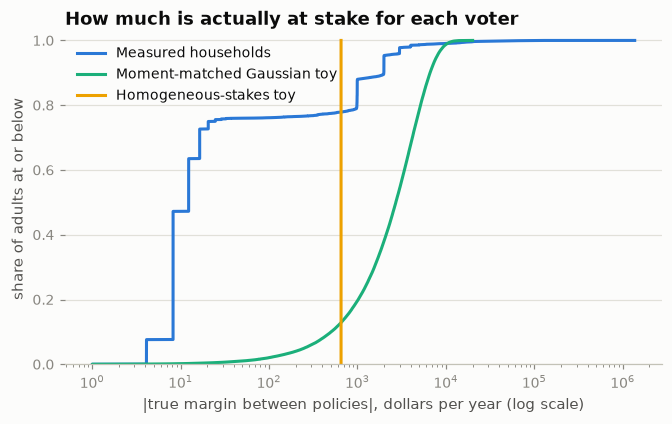

In [4]:
from democrasim import figures, toy

matched = toy.moment_matched_toy(financed, rng)
mean_stake = float(np.average(np.abs(financed.margins),
                              weights=financed.weights))
homogeneous = toy.homogeneous_toy(margin=mean_stake,
                                  n=financed.n_voters)
figures.margin_distribution(
    [financed, matched, homogeneous],
    ['Measured households', 'Moment-matched Gaussian toy',
     'Homogeneous-stakes toy'],
);

## One election

Sample 10,001 adults (probability ∝ survey weight), let each perceive their own household's stakes through the perception model, vote by plurality (perceived indifference abstains), and grade the winner against the welfare ranking.

Watch the zero-noise row: with financing on, the election is decided by the ~three-quarters of adults whose entire stake is their share of the two policies' residual cost gap (about $4 a year) — a quantity unrelated to the welfare ranking, so perfect information makes the outcome welfare-*independent*. Here the gap's sign favors the policy the metric ranks lower. Moderate noise turns those near-indifferent votes into fair coins that cancel, letting the high-stakes minority decide — misperception can *help*. The findings note shows the flip side: reverse the cost gap's sign, zero it exactly, or let trivial stakes abstain, and perfect accuracy tracks perfectly.

In [5]:
for noise_sd in (0.0, 1_000.0, 10_000.0):
    spec = d.ElectionSpec(
        perception=d.LinearGaussianPerception(noise_sd=noise_sd),
        welfare=welfare,
    )
    result = d.run_election(financed, spec, rng)
    winner = ('no winner' if result.winner < 0
              else financed.policy_labels[result.winner])
    accuracy = d.ranking_accuracy(spec.perception, financed)
    print(f'σ=${noise_sd:>8,.0f}  ranking accuracy {accuracy:.2f}  '
          f'→ {winner:<12} turnout {result.tally.turnout:.0%}  '
          f'tracked: {result.tracked}')

σ=$       0  ranking accuracy 1.00  → Policy B     turnout 100%  tracked: False
σ=$   1,000  ranking accuracy 0.58  → Policy A     turnout 100%  tracked: True
σ=$  10,000  ranking accuracy 0.51  → Policy B     turnout 100%  tracked: False


## The headline: accuracy → welfare tracking

Sweep perception noise and plot the share of elections electing the ballot-best policy against the mean probability that a voter correctly ranks the two policies for their own household (0.5 = coin flip). Two caveats the findings note unpacks: every curve here is specific to the sampled electorate size (thresholds tighten toward 0.5 as n grows — Condorcet jury logic; `democrasim.analytic_plurality_curve` gives any n in closed form), and the accuracy axis is a derived coordinate, not a sufficient statistic. On measured stakes the curve is **not monotone**: tracking is essentially perfect across a wide band of moderate accuracy, and at perfect accuracy the outcome is decided by the welfare-irrelevant *sign* of the small residual cost gap between the two policies — the homogeneous toy is the jury theorem, and the Gaussian toy hovers near a coin flip at this n. This cell runs a reduced grid to stay quick; `democrasim sweep` reproduces the full version behind `docs/findings.md`.

accuracy needed for 90% welfare tracking:
      measured: 0.529
       matched: never reaches 90%
   homogeneous: 0.513


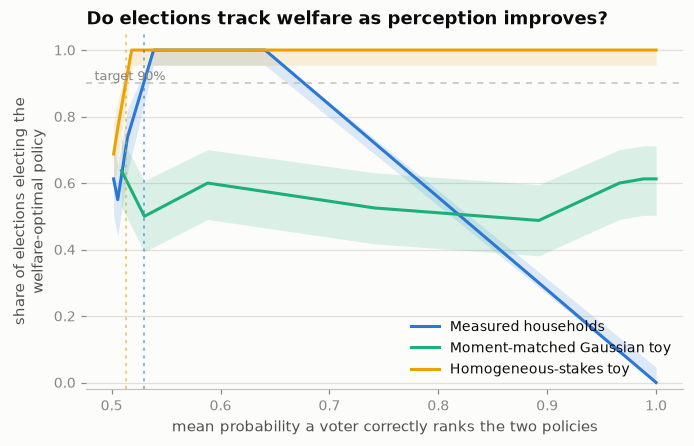

In [6]:
noise_grid = [0.0, 100.0, 300.0, 1_000.0, 3_000.0, 10_000.0,
              30_000.0, 100_000.0]
spec = d.ElectionSpec(perception=d.PERFECT_PERCEPTION,
                      welfare=welfare, n_voters=5_001)
sweeps = {}
for name, world in [('measured', financed), ('matched', matched),
                    ('homogeneous', homogeneous)]:
    sweeps[name] = d.accuracy_sweep(world, noise_grid, spec=spec,
                                    n_elections=80, seed=7)
thresholds = {name: d.find_threshold(s['mean_ranking_accuracy'],
                                     s['p_tracked'], target=0.9)
              for name, s in sweeps.items()}
print('accuracy needed for 90% welfare tracking:')
for name, value in thresholds.items():
    print(f'  {name:>12}: {value:.3f}' if np.isfinite(value)
          else f'  {name:>12}: never reaches 90%')
figures.accuracy_curve(
    [sweeps['measured'], sweeps['matched'], sweeps['homogeneous']],
    ['Measured households', 'Moment-matched Gaussian toy',
     'Homogeneous-stakes toy'],
    target=0.9,
    thresholds=[thresholds['measured'], thresholds['matched'],
                thresholds['homogeneous']],
);

## Systematic bias

Noise averages out across voters; bias does not. Give every voter a rosy view of the welfare-inferior policy — worth $b more per year than it truly is — and ask how many perceived dollars it takes to flip the election.

bias flipping the median election: $250/voter/year of perceived advantage


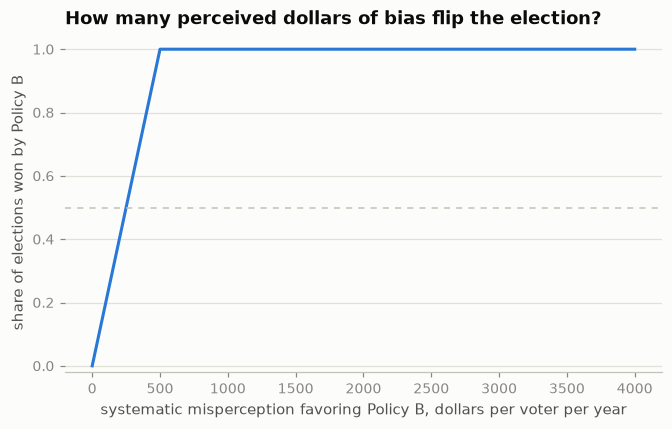

In [7]:
welfare_by_policy = welfare.per_policy(financed)
toward = int(np.argmin(welfare_by_policy))
bias_frame = d.bias_sweep(financed,
                          bias_dollars=np.linspace(0, 4_000, 9),
                          toward=toward, noise_sd=1_000.0,
                          spec=spec, n_elections=80, seed=7)
tolerance = d.find_threshold(bias_frame['bias_dollars'],
                             bias_frame[f'p_win_{toward}'],
                             target=0.5)
print(f'bias flipping the median election: '
      f'${tolerance:,.0f}/voter/year of perceived advantage')
figures.bias_curve([bias_frame], ['Measured households'],
                   toward_label=financed.policy_labels[toward]);

## Where to next

- `docs/findings.md` — the full toy-vs-measured comparison.
- `democrasim.PerceptionModel` — the interface a survey-estimated misperception distribution will drop into.
- `democrasim.Approval` / `democrasim.InstantRunoff` — the mechanism-comparison surface.

*All results above are simulation outputs from the model described in the README, under the stated perception assumption — not measurements of any real electorate.*